# Evaluation of Vision Models

## 1 Overview

## 2 Importing Libraries

In [1]:
from pathlib import Path
import gc
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from transformers import pipeline

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 Evaluation Settings and Candidate Models

In [2]:
# Reproducible evaluation
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU when available
device = 0 if torch.cuda.is_available() else -1

In [3]:
# RAF-DB folders and label files
rafdb_folder = Path(
    "../../data/raw/raf_db"
)

dataset_folder = (
    rafdb_folder / "DATASET"
)

validation_folder = (
    dataset_folder / "train"
)

testing_folder = (
    dataset_folder / "test"
)

validation_labels_file = (
    rafdb_folder / "train_labels.csv"
)

testing_labels_file = (
    rafdb_folder / "test_labels.csv"
)

# Output folder
output_folder = Path("outputs/vision")

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
# Seven RAF-DB emotion classes
vision_emotions = [
    "anger",
    "disgust",
    "fear",
    "happiness",
    "neutral",
    "sadness",
    "surprise"
]

In [5]:
# Candidate facial-expression models
models = {
    "ViT": {
        "model_id": (
            "trpakov/"
            "vit-face-expression"
        ),
        "architecture": "Vision Transformer",
        "training_data": "FER2013",
        "batch_size": 16
    },

    "ResNet-50": {
        "model_id": (
            "Celal11/"
            "resnet-50-finetuned-FER2013-0.003"
        ),
        "architecture": "ResNet-50",
        "training_data": "FER2013",
        "batch_size": 16
    },

    "ViT-Mixed-Datasets": {
        "model_id": (
            "mo-thecreator/"
            "vit-Facial-Expression-Recognition"
        ),
        "architecture": "Vision Transformer",
        "training_data": (
            "FER2013, MMI and AffectNet"
        ),
        "batch_size": 16
    },

    "ViT-FER2013": {
        "model_id": (
            "abhilash88/"
            "face-emotion-detection"
        ),
        "architecture": "Vision Transformer",
        "training_data": "FER2013",
        "batch_size": 16
    }
}

In [6]:
model_information = []

for model_name, details in models.items():
    model_information.append({
        "Model": model_name,
        "Architecture": details["architecture"],
        "Training Data": details["training_data"],
        "RAF-DB Overlap": "No",
        "Batch Size": details["batch_size"]
    })

model_information_df = pd.DataFrame(
    model_information
)

display(model_information_df)

print("Number of models:", len(models))
print("Emotions:", vision_emotions)

,Model,Architecture,Training Data,RAF-DB Overlap,Batch Size
0,ViT,Vision Transformer,FER2013,No,16
1,ResNet-50,ResNet-50,FER2013,No,16
2,ViT-Mixed-Datasets,Vision Transformer,"FER2013, MMI and AffectNet",No,16
3,ViT-FER2013,Vision Transformer,FER2013,No,16


Number of models: 4
Emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


## 4 Load RAF-DB Dataset

In [7]:
label_mapping = {
    1: "surprise",
    2: "fear",
    3: "disgust",
    4: "happiness",
    5: "sadness",
    6: "anger",
    7: "neutral"
}

In [8]:
def load_rafdb_split(labels_file, image_folder):
    data = pd.read_csv(labels_file)

    data = data[["image", "label"]].copy()

    data["emotion"] = data["label"].map(
        label_mapping
    )
    data["image_path"] = data.apply(
        lambda row: (
            image_folder
            / str(row["label"])
            / str(row["image"])
        ),
        axis=1
    )

    missing_files = (
        ~data["image_path"].apply(
            lambda path: path.is_file()
        )
    )

    if missing_files.any():
        raise FileNotFoundError(
            f"{missing_files.sum()} images "
            f"could not be located."
        )

    return data.reset_index(drop=True)

In [9]:
validation_data = load_rafdb_split(
    validation_labels_file,
    validation_folder
)

testing_data = load_rafdb_split(
    testing_labels_file,
    testing_folder
)

print(
    "Validation images:",
    len(validation_data)
)

print(
    "Testing images:",
    len(testing_data)
)

Validation images: 12271
Testing images: 3068


In [10]:
class_distribution = pd.concat([
    validation_data["emotion"]
    .value_counts()
    .reindex(vision_emotions)
    .rename("Validation"),

    testing_data["emotion"]
    .value_counts()
    .reindex(vision_emotions)
    .rename("Testing")
], axis=1).fillna(0).astype(int)

display(class_distribution)

,Validation,Testing
emotion,,
anger,705,162
disgust,717,160
fear,281,74
happiness,4772,1185
neutral,2524,680
sadness,1982,478
surprise,1290,329


## 5 Align Emotion Labels and Prepare Images

In [11]:
label_aliases = {
    "angry": "anger",
    "anger": "anger",

    "disgusted": "disgust",
    "disgust": "disgust",

    "fearful": "fear",
    "fear": "fear",

    "happy": "happiness",
    "happiness": "happiness",
    "joy": "happiness",

    "neutral": "neutral",

    "sad": "sadness",
    "sadness": "sadness",

    "surprised": "surprise",
    "surprise": "surprise",

    "label_0": "anger",
    "label_1": "disgust",
    "label_2": "fear",
    "label_3": "happiness",
    "label_4": "sadness",
    "label_5": "surprise",
    "label_6": "neutral"
}


def normalise_vision_label(label):
    label = str(label).strip().lower()

    return label_aliases.get(
        label,
        label
    )

In [12]:
def load_image(image_path):
    return Image.open(
        image_path
    ).convert("RGB")

In [13]:
sample_image = load_image(
    validation_data.loc[
        0,
        "image_path"
    ]
)

print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)
print(
    "Dataset emotions:",
    sorted(
        validation_data["emotion"].unique()
    )
)

Image size: (100, 100)
Image mode: RGB
Dataset emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


## 6 Define Model Prediction Functions

In [14]:
def run_vision_model(model_details, data):
    model_id = model_details["model_id"]
    batch_size = model_details["batch_size"]

    loading_start = time.perf_counter()

    classifier = pipeline(
        task="image-classification",
        model=model_id,
        device=device,
        top_k=None
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    loading_time = (
        time.perf_counter() - loading_start
    )

    predictions = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    for start_index in range(
        0,
        len(data),
        batch_size
    ):
        batch = data.iloc[
            start_index:
            start_index + batch_size
        ]

        images = [
            load_image(image_path)
            for image_path in batch["image_path"]
        ]

        batch_outputs = classifier(
            images,
            batch_size=batch_size
        )

        if (
            batch_outputs
            and isinstance(batch_outputs[0], dict)
        ):
            batch_outputs = [batch_outputs]

        for prediction_scores in batch_outputs:
            common_scores = {}

            for item in prediction_scores:
                emotion = normalise_vision_label(
                    item["label"]
                )

                if emotion in vision_emotions:
                    common_scores[emotion] = float(
                        item["score"]
                    )

            if not common_scores:
                raise ValueError(
                    "The model returned no supported "
                    "emotion labels."
                )

            predictions.append(
                max(
                    common_scores,
                    key=common_scores.get
                )
            )

        for image in images:
            image.close()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - inference_start
    )

    del classifier

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "predictions": predictions,
        "loading_time": loading_time,
        "inference_time": inference_time
    }

## 7 Model Evaluation on Validation Data

In [15]:
def calculate_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(
            actual,
            predicted
        ),
        "Macro Precision": precision_score(
            actual,
            predicted,
            labels=vision_emotions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            actual,
            predicted,
            labels=vision_emotions,
            average="macro",
            zero_division=0
        ),
        "Macro-F1": f1_score(
            actual,
            predicted,
            labels=vision_emotions,
            average="macro",
            zero_division=0
        )
    }

In [16]:
validation_results = []
validation_predictions = {}

actual_validation_labels = (
    validation_data["emotion"].tolist()
)

for model_name, model_details in models.items():
    print(f"Evaluating {model_name}...")

    evaluation = run_vision_model(
        model_details,
        validation_data
    )

    predicted_labels = evaluation["predictions"]

    if len(predicted_labels) != len(
        actual_validation_labels
    ):
        raise ValueError(
            f"{model_name} returned an incorrect "
            "number of predictions."
        )

    metrics = calculate_metrics(
        actual_validation_labels,
        predicted_labels
    )

    validation_predictions[model_name] = (
        predicted_labels
    )

    validation_results.append({
        "Model": model_name,
        **metrics,
        "Loading Time": evaluation["loading_time"],
        "Inference Time": evaluation["inference_time"],
        "ms per Image": (
            evaluation["inference_time"]
            / len(validation_data)
            * 1000
        )
    })

    print(
        "Macro-F1:",
        round(metrics["Macro-F1"], 4)
    )

Evaluating ViT...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 8127.16it/s]
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Macro-F1: 0.4997
Evaluating ResNet-50...


Loading weights: 100%|██████████| 320/320 [00:00<00:00, 30263.30it/s]


Macro-F1: 0.4931
Evaluating ViT-Mixed-Datasets...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 7116.29it/s]


Macro-F1: 0.5824
Evaluating ViT-FER2013...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 7197.62it/s]


Macro-F1: 0.5032


In [17]:
validation_results_df = pd.DataFrame(
    validation_results
)

display(validation_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Image
0,ViT,0.643224,0.590666,0.543477,0.499652,2.641230,102.243500,8.332125
1,ResNet-50,0.589764,0.543218,0.519430,0.493116,2.596011,47.701486,3.887335
2,ViT-Mixed-Datasets,0.699373,0.592828,0.607531,0.582388,2.236823,119.781345,9.761335
3,ViT-FER2013,0.656752,0.580801,0.534286,0.503212,2.253444,127.155780,10.362300


## 8 Comparing and Selecting the Best Model

In [18]:
validation_results_df = (
    validation_results_df
    .sort_values(
        by=["Macro-F1", "Inference Time"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(validation_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Image
0,ViT-Mixed-Datasets,0.699373,0.592828,0.607531,0.582388,2.236823,119.781345,9.761335
1,ViT-FER2013,0.656752,0.580801,0.534286,0.503212,2.253444,127.155780,10.362300
2,ViT,0.643224,0.590666,0.543477,0.499652,2.641230,102.243500,8.332125
3,ResNet-50,0.589764,0.543218,0.519430,0.493116,2.596011,47.701486,3.887335


In [19]:
selected_model_name = validation_results_df.loc[
    0,
    "Model"
]

selected_model_details = models[
    selected_model_name
]

selected_validation_predictions = (
    validation_predictions[
        selected_model_name
    ]
)

print(
    "Selected model:",
    selected_model_name
)

print(
    "Validation Macro-F1:",
    round(
        validation_results_df.loc[
            0,
            "Macro-F1"
        ],
        4
    )
)

print(
    "Inference time:",
    round(
        validation_results_df.loc[
            0,
            "Inference Time"
        ],
        2
    ),
    "seconds"
)

print(
    "Processing time:",
    round(
        validation_results_df.loc[
            0,
            "ms per Image"
        ],
        2
    ),
    "ms per image"
)

Selected model: ViT-Mixed-Datasets
Validation Macro-F1: 0.5824
Inference time: 119.78 seconds
Processing time: 9.76 ms per image


## 9 Final Test Evaluation

In [20]:
actual_test_labels = (
    testing_data["emotion"].tolist()
)

test_evaluation = run_vision_model(
    selected_model_details,
    testing_data
)

test_predictions = (
    test_evaluation["predictions"]
)

if len(test_predictions) != len(
    actual_test_labels
):
    raise ValueError(
        "The selected model returned an incorrect "
        "number of test predictions."
    )

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4940.84it/s]


In [21]:
test_metrics = calculate_metrics(
    actual_test_labels,
    test_predictions
)

test_results_df = pd.DataFrame([{
    "Model": selected_model_name,
    **test_metrics,
    "Loading Time": test_evaluation["loading_time"],
    "Inference Time": test_evaluation["inference_time"],
    "ms per Image": (
        test_evaluation["inference_time"]
        / len(testing_data)
        * 1000
    )
}])

display(test_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Image
0,ViT-Mixed-Datasets,0.697197,0.589126,0.614119,0.581952,2.303628,33.174006,10.812909


In [22]:
print(
    "Selected model:",
    selected_model_name
)

print(
    "Test Macro-F1:",
    round(
        test_metrics["Macro-F1"],
        4
    )
)

print(
    "Test Accuracy:",
    round(
        test_metrics["Accuracy"],
        4
    )
)

print(
    "Processing time:",
    round(
        test_results_df.loc[
            0,
            "ms per Image"
        ],
        2
    ),
    "ms per image"
)

Selected model: ViT-Mixed-Datasets
Test Macro-F1: 0.582
Test Accuracy: 0.6972
Processing time: 10.81 ms per image


## 10 Confusion Matrix

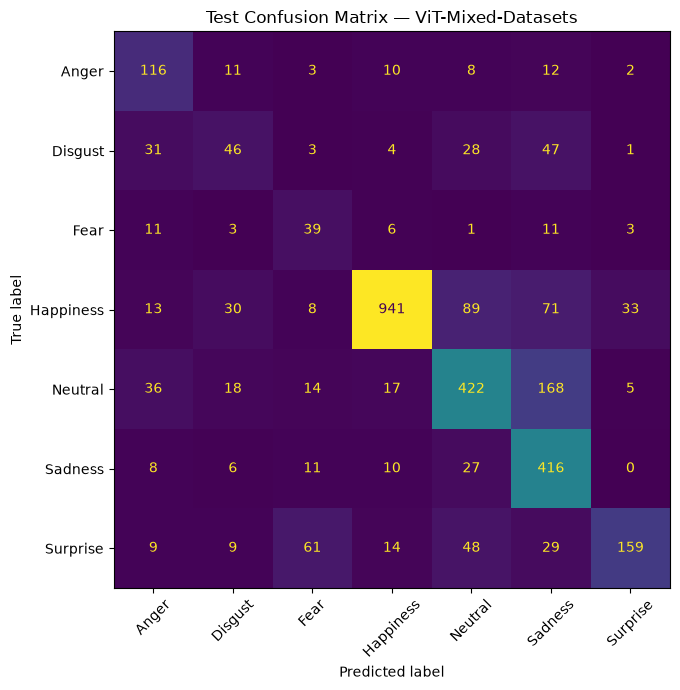

In [23]:
figure, axis = plt.subplots(
    figsize=(8, 7)
)

ConfusionMatrixDisplay.from_predictions(
    actual_test_labels,
    test_predictions,
    labels=vision_emotions,
    display_labels=[
        emotion.capitalize()
        for emotion in vision_emotions
    ],
    xticks_rotation=45,
    ax=axis,
    colorbar=False
)

axis.set_title(
    f"Test Confusion Matrix — {selected_model_name}"
)

plt.tight_layout()

plt.savefig(
    output_folder
    / "selected_vision_model_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

## 11 Saving Results

In [24]:
validation_results_df.to_csv(
    output_folder / "vision_model_comparison.csv",
    index=False
)

test_results_df.to_csv(
    output_folder / "selected_vision_model_test_results.csv",
    index=False
)

In [25]:
test_predictions_df = pd.DataFrame({
    "Image": testing_data["image"],
    "Actual Emotion": actual_test_labels,
    "Predicted Emotion": test_predictions
})

test_predictions_df.to_csv(
    output_folder / "selected_vision_model_test_predictions.csv",
    index=False
)

print("Results saved in:", output_folder)

Results saved in: outputs\vision


## 12 Conclusion